In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("Concrete_Data.csv")
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [53]:
df.columns = [
    'cement_kg_m3',
    'slag_kg_m3',
    'fly_ash_kg_m3',
    'water_kg_m3',
    'superplasticizer_kg_m3',
    'coarse_agg_kg_m3',
    'fine_agg_kg_m3',
    'age_days',
    'strength_mpa'  # Target column
]

df.head()

,cement_kg_m3,slag_kg_m3,fly_ash_kg_m3,water_kg_m3,superplasticizer_kg_m3,coarse_agg_kg_m3,fine_agg_kg_m3,age_days,strength_mpa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [54]:
df.describe()

,cement_kg_m3,slag_kg_m3,fly_ash_kg_m3,water_kg_m3,superplasticizer_kg_m3,coarse_agg_kg_m3,fine_agg_kg_m3,age_days,strength_mpa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [55]:
X = df.drop(columns=['strength_mpa']).to_numpy()
y = df["strength_mpa"].to_numpy()

feature_names = df.drop(columns=["strength_mpa"]).columns.to_list() #save feature names for error analysis later

<Axes: >

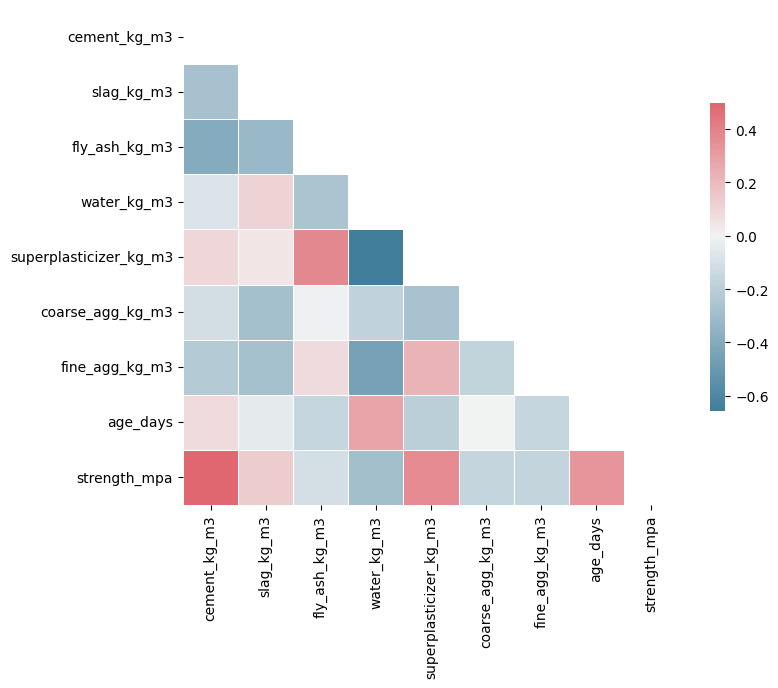

In [61]:
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
cmap = sns.diverging_palette(230, 10, as_cmap=True)
f, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(df.corr(), mask=mask, cmap=cmap, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_pipeline = Pipeline([
    ('scaler', StandardScaler()), #placeholder scaler
    ('model', Ridge()) #placeholder model
])

In [32]:
multi_model_param_grid = [
    {
        'model': [LinearRegression()],
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    {
        'model': [Ridge()],
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    {
        'model': [Lasso()],
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'],
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    {
        'model': [RandomForestRegressor(random_state=42)],
        'scaler': ['passthrough'],
        'model__max_depth': [3, 5, 8, 12, None],
        'model__min_samples_leaf': [1, 2, 4]
    },
    {
        'model': [GradientBoostingRegressor(random_state=42)],
        'scaler': ['passthrough'],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 1.0]
    }
]

In [33]:
cv_tuner = GridSearchCV(
    estimator=base_pipeline,
    param_grid=multi_model_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

In [34]:
cv_tuner.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LinearRegression()], 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, {'model': [Ridge()], 'model__alpha': [0.01, 0.1, ...], 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls t

In [35]:
results = pd.DataFrame(cv_tuner.cv_results_)

results['model_name'] = results['param_model'].apply(lambda x: x.__class__.__name__)

leaderboard = results[['model_name', 'param_scaler', 'mean_test_score', 'std_test_score', 'rank_test_score']]

leaderboard['rmse_score'] = -leaderboard['mean_test_score']
leaderboard = leaderboard.drop(columns=['mean_test_score']).sort_values(by='rank_test_score')

print("--- MULTI-MODEL CROSS-VALIDATION LEADERBOARD ---")
print(leaderboard.to_string(index=False))

best_overall_pipeline = cv_tuner.best_estimator_
print(f"\nWinning Model Architecture: {best_overall_pipeline}")

--- MULTI-MODEL CROSS-VALIDATION LEADERBOARD ---
               model_name     param_scaler  std_test_score  rank_test_score  rmse_score
GradientBoostingRegressor      passthrough        0.441054                1    5.097823
    RandomForestRegressor      passthrough        0.473724                2    5.132452
    RandomForestRegressor      passthrough        0.467007                3    5.142030
GradientBoostingRegressor      passthrough        0.589863                4    5.248678
    RandomForestRegressor      passthrough        0.471728                5    5.286325
    RandomForestRegressor      passthrough        0.461231                6    5.307776
    RandomForestRegressor      passthrough        0.460226                7    5.417409
    RandomForestRegressor      passthrough        0.456228                8    5.502817
    RandomForestRegressor      passthrough        0.520438                9    5.652477
    RandomForestRegressor      passthrough        0.520290             

C:\Users\thoma\AppData\Local\Temp\ipykernel_14824\654827480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaderboard['rmse_score'] = -leaderboard['mean_test_score']


In [36]:
best_params = cv_tuner.best_params_
print(f"Optimal Hyperparameters: {best_params}")

Optimal Hyperparameters: {'model': GradientBoostingRegressor(random_state=42), 'model__learning_rate': 0.1, 'model__subsample': 0.8, 'scaler': 'passthrough'}


In [37]:
best_pipeline = cv_tuner.best_estimator_

In [38]:
final_predictions = best_pipeline.predict(X_test)

test_rmse = root_mean_squared_error(y_test, final_predictions)
test_r2 = r2_score(y_test, final_predictions)

print(f"Unbiased Post-Training Test RMSE: {test_rmse:.2f}")
print(f"Unbiased Post-Training Test R² Score: {test_r2:.4f}")

Unbiased Post-Training Test RMSE: 5.40
Unbiased Post-Training Test R² Score: 0.8868


In [39]:
# Extract the named steps to see who won
winning_scaler = best_pipeline.named_steps['scaler']
winning_model = best_pipeline.named_steps['model']

print(f"🥇 Winning Architecture: {winning_model.__class__.__name__}")
print(f"🛠️ Winning Scaler configuration: {winning_scaler}")
print(f"⚙️ Winning Model Parameters: {winning_model.get_params()}")

🥇 Winning Architecture: GradientBoostingRegressor
🛠️ Winning Scaler configuration: passthrough
⚙️ Winning Model Parameters: {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.8, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [40]:
y_pred = best_pipeline.predict(X_test)

residuals = y_test - y_pred

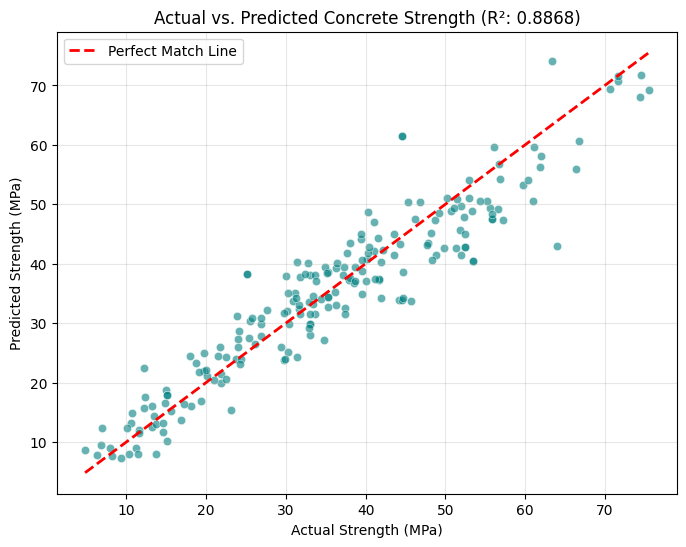

In [41]:
# prediction accuracy plot

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
# Draw a perfect 45-degree match line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Match Line")

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"Actual vs. Predicted Concrete Strength (R²: 0.8868)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

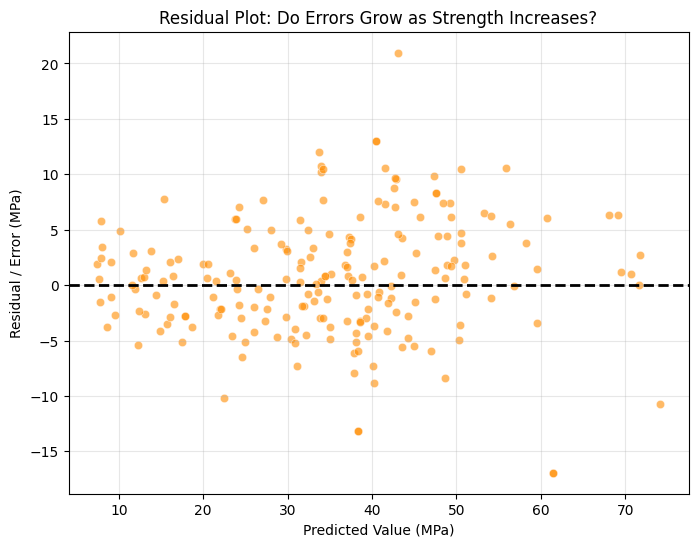

In [42]:
# residual plot

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='darkorange')
plt.axhline(y=0, color='black', linestyle='--', lw=2)

plt.xlabel("Predicted Value (MPa)")
plt.ylabel("Residual / Error (MPa)")
plt.title("Residual Plot: Do Errors Grow as Strength Increases?")
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
# extra analysis: find worst 5% failure cases

df_test_analysis = pd.DataFrame(X_test, columns=feature_names)
df_test_analysis['actual_strength'] = y_test
df_test_analysis['predicted_strength'] = y_pred
df_test_analysis['absolute_error'] = np.abs(residuals)

# Sort the table to see the top 5 largest prediction errors
worst_failures = df_test_analysis.sort_values(by='absolute_error', ascending=False).head()

print("\n🚨 MODEL'S WORST 5 PREDICTION FAILURES:")
print(worst_failures[['age_days', 'cement_kg_m3', 'actual_strength', 'predicted_strength', 'absolute_error']])


🚨 MODEL'S WORST 5 PREDICTION FAILURES:
     age_days  cement_kg_m3  actual_strength  predicted_strength  \
382        28         505.0            64.02           43.048417   
908        28         313.0            44.52           61.449516   
971        28         312.7            44.52           61.449516   
919        28         313.0            25.10           38.308981   
982        28         312.7            25.10           38.308981   

     absolute_error  
382       20.971583  
908       16.929516  
971       16.929516  
919       13.208981  
982       13.208981  
